<a href="https://colab.research.google.com/github/kondreddygarivani-bit/project-3/blob/main/W3_CUST_CHURN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Customer-Churn-Records.csv to Customer-Churn-Records.csv


In [ ]:
# STEP 1 - IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# MACHINE LEARNING LIBRARIES

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [ ]:
df = pd.read_csv("Customer-Churn-Records.csv")
# STEP 3 - BASIC INFORMATION

print("\nFIRST 5 ROWS")
print(df.head())

print("\nSHAPE")
print(df.shape)

print("\nDATA TYPES")
print(df.dtypes)

# STEP 4 - CHECK MISSING VALUES

print("\nMISSING VALUES")
print(df.isnull().sum())


FIRST 5 ROWS
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  Complain  Satisfaction Score Card Type  \
0        101348.88       1         1                   2   DIAMOND   
1   

In [ ]:
# STEP 5 - REMOVE UNNECESSARY COLUMNS

df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# STEP 6 - ENCODE CATEGORICAL VARIABLES

encoder = LabelEncoder()

df['Gender'] = encoder.fit_transform(df['Gender'])

df['Geography'] = encoder.fit_transform(df['Geography'])

# STEP 7 - FEATURES AND TARGET

X = df.drop('Exited', axis=1)

y = df['Exited']

print("\nFEATURES")
print(X.head())



FEATURES
   CreditScore  Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619          0       0   42       2       0.00              1   
1          608          2       0   41       1   83807.86              1   
2          502          0       0   42       8  159660.80              3   
3          699          0       0   39       1       0.00              2   
4          850          2       0   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  Complain  Satisfaction Score  \
0          1               1        101348.88         1                   2   
1          0               1        112542.58         1                   3   
2          1               0        113931.57         1                   3   
3          0               0         93826.63         0                   5   
4          1               1         79084.10         0                   5   

  Card Type  Point Earned  
0   DIAMOND           464  
1 

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# STEP 8 - TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Encode 'Card Type' specifically for X_train and X_test
card_type_encoder = LabelEncoder()

# Fit and transform on X_train
X_train['Card Type'] = card_type_encoder.fit_transform(X_train['Card Type'])
# Transform on X_test using the fitted encoder
X_test['Card Type'] = card_type_encoder.transform(X_test['Card Type'])


# STEP 9 - FEATURE SCALING

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
# STEP 10 - LOGISTIC REGRESSION MODEL

print("\nLOGISTIC REGRESSION")

lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))


LOGISTIC REGRESSION
Accuracy : 0.999


In [ ]:
# STEP 11 - RANDOM FOREST MODEL

print("\nRANDOM FOREST")

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))


RANDOM FOREST
Accuracy : 0.999



CONFUSION MATRIX
[[1606    1]
 [   1  392]]


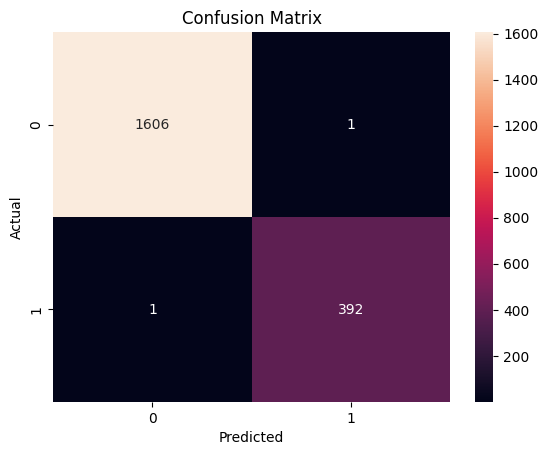

In [ ]:
# STEP 12 - CONFUSION MATRIX

print("\nCONFUSION MATRIX")

cm = confusion_matrix(y_test, y_pred_rf)

print(cm)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
# STEP 13 - CLASSIFICATION REPORT

print("\nCLASSIFICATION REPORT")

print(classification_report(y_test, y_pred_rf))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1607
           1       1.00      1.00      1.00       393

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

